In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler


Carregamento dos dados

In [47]:
# =============
# 2
# =============
# Carregando o dataset Iris
iris = load_iris(as_frame=True)

# Features
X = iris.data.copy()

# Rótulos reais das espécies
y = iris.target.copy()

# Nomes das variáveis
feature_names = iris.feature_names

# Padronizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA para visualização em 2 dimensões
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Dados preparados com sucesso!")
print("Formato de X_scaled:", X_scaled.shape)
print("Formato de X_pca:", X_pca.shape)

Dados preparados com sucesso!
Formato de X_scaled: (150, 4)
Formato de X_pca: (150, 2)


## Exercício 1 — Testando diferentes valores de `eps` e `min_samples` no DBSCAN

Neste exercício, o objetivo é analisar como os parâmetros `eps` e `min_samples` influenciam o comportamento do algoritmo DBSCAN.

O parâmetro `eps` define o raio de vizinhança utilizado para decidir quais pontos estão próximos entre si. Já o parâmetro `min_samples` define a quantidade mínima de pontos necessária para formar uma região considerada densa.

Como o DBSCAN é um algoritmo baseado em densidade, pequenas alterações nesses parâmetros podem modificar bastante os resultados, alterando a quantidade de clusters encontrados e a quantidade de pontos classificados como ruído (`-1`).

===========================================================================

In [48]:
# =============
# 3
# =============

# =====================================================
# aqui há a realização dos testes que o DBSCAN está usasando.
# varios valores de "eps" e varios valores de "min_samples"
# O eps é o raio de vizinhança. Ele define até que distância um ponto pode estar de outro para serem considerados próximos.
# =====================================================
lista_raios_vizinhanca = [0.3, 0.5, 0.7, 0.9, 1.1]

# =====================================================
# é a quantidade mínima de pontos necessária para formar uma região densa.
# O algoritmo é mais exigente, porque precisa de mais pontos próximos para formar um cluster.
# =====================================================
lista_minimos_pontos_densos = [3, 5, 7, 10]

# =====================================================
# Lista onde vamos guardar os resultados dos testes
# =====================================================
lista_resultados_dbscan = []

# =====================================================
# Testando todas as combinações de parâmetros
# =====================================================
# O primeiro for percorre cada valor de raio_vizinhanca.
# O segundo for percorre cada valor de minimo_pontos_densos.
#
# Assim, o código testa todas as combinações possíveis.
# =====================================================
for raio_vizinhanca in lista_raios_vizinhanca:
    for minimo_pontos_densos in lista_minimos_pontos_densos:

        # =====================================================
        # Criando o modelo DBSCAN com os parâmetros atuais
        # =====================================================
        modelo_dbscan = DBSCAN(
            eps=raio_vizinhanca,
            min_samples=minimo_pontos_densos
        )


        # =====================================================
        # Treinando o modelo e gerando os rótulos dos clusters
        # =====================================================
        # O fit_predict aplica o DBSCAN nos dados padronizados.
        #
        # O resultado fica em rotulos_clusters.
        # Cada ponto recebe um número de cluster.
        #
        # Quando o valor é -1, significa que o ponto foi
        # classificado como ruído/outlier.
        # =====================================================
        rotulos_clusters = modelo_dbscan.fit_predict(X_scaled)

        # =====================================================
        # Identificando os clusters encontrados
        # set(rotulos_clusters) pega apenas os rótulos únicos.
        # =====================================================
        clusters_encontrados = set(rotulos_clusters)

        # =====================================================
        # Removendo o ruído da contagem de clusters
        # =====================================================
        # No DBSCAN, o rótulo -1 representa ruído.
        # Por isso, ele não deve ser contado como cluster válido.
        # =====================================================
        clusters_validos = [
            cluster
            for cluster in clusters_encontrados
            if cluster != -1
        ]

        # =====================================================
        # Contando quantos clusters válidos foram encontrados
        # =====================================================
        quantidade_clusters = len(clusters_validos)


        # =====================================================
        # Contando quantos pontos foram classificados como ruído
        # =====================================================
        # Aqui contamos quantos pontos receberam o rótulo -1.
        # =====================================================
        quantidade_ruido = np.sum(rotulos_clusters == -1)

        # =====================================================
        # Calculando o ARI
        # =====================================================
        # O ARI compara os clusters encontrados pelo DBSCAN
        # com os rótulos reais das espécies do Iris.
        #
        # Quanto mais próximo de 1, melhor.
        # =====================================================
        valor_ari = adjusted_rand_score(y, rotulos_clusters)


        # =====================================================
        # Calculando a Silhouette
        # =====================================================
        # A Silhouette mede se os clusters ficaram bem separados.
        #
        # Ela só pode ser calculada quando existem pelo menos
        # 2 clusters válidos.
        #
        # Se houver menos de 2 clusters, usamos np.nan,
        # que significa "não calculável".
        # =====================================================
        if quantidade_clusters >= 2:
            valor_silhouette = silhouette_score(X_scaled, rotulos_clusters)
        else:
            valor_silhouette = np.nan


        # =====================================================
        # Salvando os resultados desta combinação
        # =====================================================
        # Cada combinação testada vira uma linha na tabela final.
        # =====================================================
        lista_resultados_dbscan.append({
            "raio_vizinhanca_eps": raio_vizinhanca,
            "minimo_pontos_densos": minimo_pontos_densos,
            "quantidade_clusters": quantidade_clusters,
            "quantidade_ruido": quantidade_ruido,
            "ARI": valor_ari,
            "Silhouette": valor_silhouette
        })


# =====================================================
# Transformando os resultados em uma tabela
# =====================================================
tabela_resultados_dbscan = pd.DataFrame(lista_resultados_dbscan)
# =====================================================
# Exibindo a tabela final
# =====================================================
tabela_resultados_dbscan

,raio_vizinhanca_eps,minimo_pontos_densos,quantidade_clusters,quantidade_ruido,ARI,Silhouette
0,0.3,3,10,84,0.173758,-0.147300
1,0.3,5,3,120,0.087595,-0.194195
2,0.3,7,2,129,0.064077,0.175098
3,0.3,10,0,150,0.000000,NaN
4,0.5,3,7,17,0.452575,0.159710
5,0.5,5,2,34,0.442099,0.356516
6,0.5,7,5,46,0.468338,0.139148
7,0.5,10,3,89,0.279191,0.009426
8,0.7,3,2,5,0.550317,0.508067
9,0.7,5,2,6,0.540077,0.523401


In [49]:
# =============
# 4
# =============

# =====================================================
# Ordenando os resultados do melhor para o pior ARI
# =====================================================
tabela_resultados_ordenada_ari = tabela_resultados_dbscan.sort_values(
    by="ARI",
    ascending=False
)

tabela_resultados_ordenada_ari

,raio_vizinhanca_eps,minimo_pontos_densos,quantidade_clusters,quantidade_ruido,ARI,Silhouette
16,1.1,3,2,1,0.558371,0.504646
17,1.1,5,2,2,0.555790,0.551772
19,1.1,10,2,3,0.553582,0.538288
18,1.1,7,2,3,0.553582,0.538288
12,0.9,3,2,4,0.551755,0.521697
13,0.9,5,2,4,0.551755,0.521697
8,0.7,3,2,5,0.550317,0.508067
9,0.7,5,2,6,0.540077,0.523401
14,0.9,7,2,6,0.540077,0.522457
15,0.9,10,2,8,0.534382,0.510808



---

Visualizando a quantidade de ruído

---

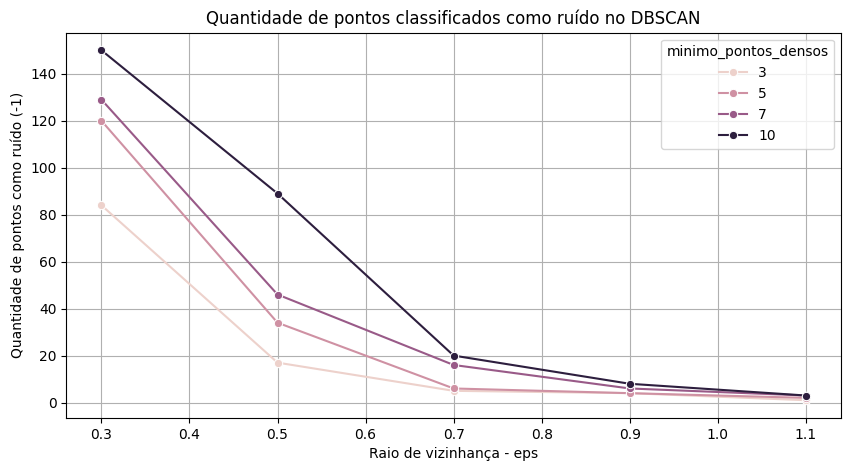

In [50]:
# =============
# 5
# =============

# =====================================================
# Visualizando a quantidade de pontos classificados como ruído
# =====================================================
# Este gráfico mostra como a quantidade de ruído muda
# conforme alteramos:
# - o raio de vizinhança, chamado de eps
# - o mínimo de pontos densos, chamado de min_samples
#
# No DBSCAN, pontos classificados como ruído recebem o rótulo -1.
# =====================================================

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=tabela_resultados_dbscan,
    x="raio_vizinhanca_eps",
    y="quantidade_ruido",
    hue="minimo_pontos_densos",
    marker="o"
)

plt.title("Quantidade de pontos classificados como ruído no DBSCAN")
plt.xlabel("Raio de vizinhança - eps")
plt.ylabel("Quantidade de pontos como ruído (-1)")
plt.grid(True)
plt.show()


---


Visualizando a quantidade de clusters

---



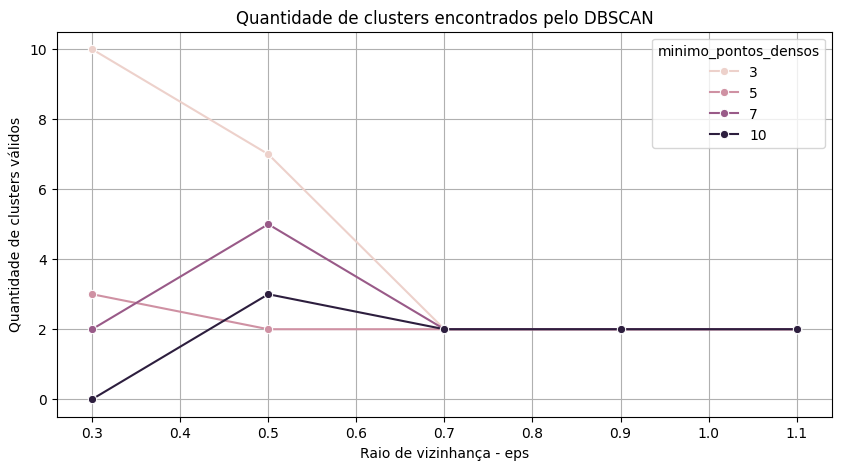

In [51]:
# =============
# 6
# =============

# =====================================================
# Visualizando a quantidade de clusters encontrados
# =====================================================
# Este gráfico mostra quantos clusters o DBSCAN encontrou
# para cada combinação de parâmetros.
# =====================================================

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=tabela_resultados_dbscan,
    x="raio_vizinhanca_eps",
    y="quantidade_clusters",
    hue="minimo_pontos_densos",
    marker="o"
)

plt.title("Quantidade de clusters encontrados pelo DBSCAN")
plt.xlabel("Raio de vizinhança - eps")
plt.ylabel("Quantidade de clusters válidos")
plt.grid(True)
plt.show()

---

Visualizando os agrupamentos no PCA

---



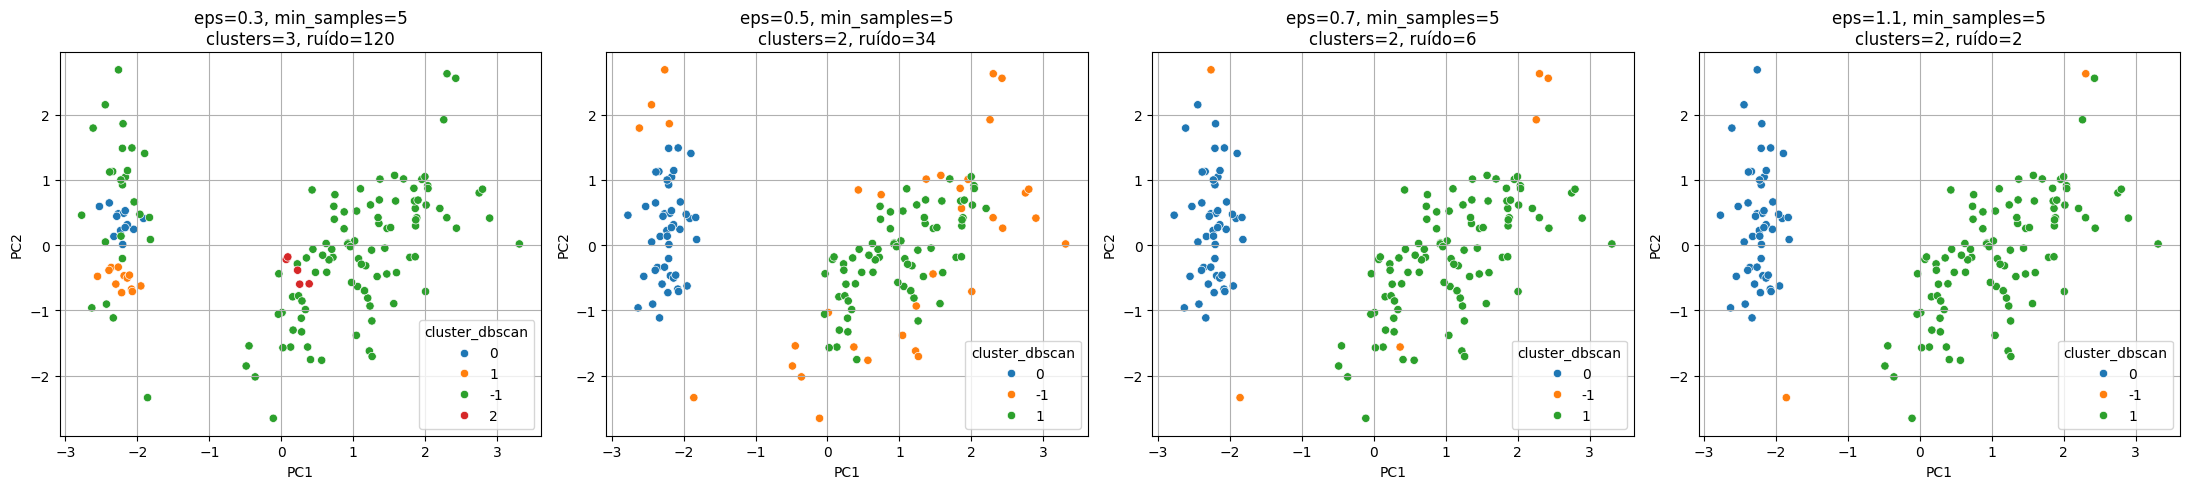

In [52]:
# =====================================================
# Visualizando os agrupamentos do DBSCAN no PCA
# =====================================================
# Aqui vamos observar visualmente como o DBSCAN agrupou os dados.
#
# Como o conjunto Iris tem 4 variáveis, usamos o PCA para reduzir
# os dados para 2 componentes principais:
# - PC1
# - PC2
#
# Isso permite visualizar os clusters em um gráfico 2D.
# =====================================================

# Combinações escolhidas para visualização
# Cada tupla representa:
# (raio_vizinhanca_eps, minimo_pontos_densos)
combinacoes_para_visualizar = [
    (0.3, 5),
    (0.5, 5),
    (0.7, 5),
    (1.1, 5)
]

# Criando os gráficos lado a lado
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for eixo_grafico, (raio_vizinhanca, minimo_pontos_densos) in zip(axes, combinacoes_para_visualizar):
    # ===========================================================================================
    # Criando o modelo DBSCAN com a combinação atual
    # ===========================================================================================
    modelo_dbscan = DBSCAN(
        eps=raio_vizinhanca,
        min_samples=minimo_pontos_densos
    )
    # ===========================================================================================
    # Treinando o modelo e gerando os rótulos dos clusters
    # ===========================================================================================
    rotulos_clusters = modelo_dbscan.fit_predict(X_scaled)

    # ===========================================================================================
    # Criando uma tabela para facilitar a visualização no gráfico
    # ===========================================================================================
    tabela_pca_dbscan = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
    tabela_pca_dbscan["cluster_dbscan"] = rotulos_clusters.astype(str)

    # ===========================================================================================
    # Contando clusters válidos, sem considerar o ruído (-1)
    # ===========================================================================================
    clusters_validos = [
        cluster
        for cluster in set(rotulos_clusters)
        if cluster != -1
    ]

    quantidade_clusters = len(clusters_validos)
    quantidade_ruido = np.sum(rotulos_clusters == -1)

    # ===========================================================================================
    # Criando o gráfico
    # ===========================================================================================
    sns.scatterplot(
        data=tabela_pca_dbscan,
        x="PC1",
        y="PC2",
        hue="cluster_dbscan",
        palette="tab10",
        ax=eixo_grafico
    )

    eixo_grafico.set_title(
        f"eps={raio_vizinhanca}, min_samples={minimo_pontos_densos}\n"
        f"clusters={quantidade_clusters}, ruído={quantidade_ruido}"
    )

    eixo_grafico.set_xlabel("PC1")
    eixo_grafico.set_ylabel("PC2")
    eixo_grafico.grid(True)

plt.tight_layout()
plt.show()

### Análise dos resultados do Exercício 1

Ao testar diferentes valores de `eps` e `min_samples`, foi possível observar que o DBSCAN é bastante sensível à escolha desses parâmetros.

Quando o valor de `eps` foi muito baixo, como `0.3`, o algoritmo classificou muitos pontos como ruído. No caso mais extremo, com `eps = 0.3` e `min_samples = 10`, todos os 150 pontos foram classificados como ruído, e nenhum cluster foi formado. Isso aconteceu porque o raio de vizinhança ficou muito pequeno e o critério de densidade ficou muito rígido.

Conforme o valor de `eps` aumentou, a quantidade de ruído diminuiu. Os melhores resultados de ARI apareceram principalmente com `eps = 1.1`, `eps = 0.9` e `eps = 0.7`. Isso indica que, para este conjunto de dados, valores maiores de `eps` permitiram conectar melhor os pontos e formar agrupamentos mais estáveis.

Também foi possível observar que o parâmetro `min_samples` influencia o nível de exigência do algoritmo. Valores maiores tornam o DBSCAN mais rigoroso, exigindo mais pontos próximos para formar uma região densa. Por isso, em alguns casos, o aumento de `min_samples` elevou a quantidade de pontos classificados como ruído.

O melhor resultado pelo ARI foi obtido com `eps = 1.1` e `min_samples = 3`, com ARI igual a aproximadamente `0.558`. Nessa configuração, o DBSCAN encontrou 2 clusters e classificou apenas 1 ponto como ruído.

Apesar do conjunto Iris possuir 3 espécies reais, o DBSCAN encontrou principalmente 2 clusters nas melhores configurações. Isso pode ocorrer porque algumas espécies, como versicolor e virginica, possuem características mais parecidas e podem ser agrupadas juntas por um método baseado em densidade.

Assim, conclui-se que a escolha de `eps` e `min_samples` é essencial para o desempenho do DBSCAN. Um valor muito baixo de `eps` pode gerar excesso de ruído, enquanto valores maiores podem reduzir o ruído e formar clusters mais consistentes.



---




---


## Exercício 2 — Comparando MinMaxScaler com StandardScaler

Neste exercício, vamos comparar duas formas de escalonamento dos dados:

- `StandardScaler`: transforma os dados para média 0 e desvio padrão 1.
- `MinMaxScaler`: transforma os dados para um intervalo entre 0 e 1.

Essa comparação é importante porque o DBSCAN é baseado em distância. Portanto, a forma como os dados são escalonados pode alterar a quantidade de clusters encontrados, a quantidade de pontos classificados como ruído e as métricas de avaliação.

---



In [53]:
# =====================================================
# EXERCÍCIO 2 — Comparando StandardScaler com MinMaxScaler
# =====================================================
# O objetivo é verificar se a forma de escalonamento muda
# os resultados do DBSCAN.
#
# Vamos comparar:
# - StandardScaler: média 0 e desvio padrão 1
# - MinMaxScaler: valores entre 0 e 1
# =====================================================

# =====================================================
# Criando os dois tipos de escalonamento
# =====================================================

escalonador_standard = StandardScaler()
dados_standard = escalonador_standard.fit_transform(X)

escalonador_minmax = MinMaxScaler()
dados_minmax = escalonador_minmax.fit_transform(X)


# =====================================================
# Valores que serão testados no DBSCAN
# =====================================================
# Atenção:
# Como o MinMaxScaler coloca os dados entre 0 e 1,
# usamos valores menores de eps para ele.
# =====================================================

lista_raios_standard = [0.3, 0.5, 0.7, 0.9, 1.1]
lista_raios_minmax = [0.05, 0.10, 0.15, 0.20, 0.30]

lista_minimos_pontos_densos = [3, 5, 7, 10]


# =====================================================
# Função para testar o DBSCAN
# =====================================================
# Essa função recebe:
# - os dados escalonados
# - o nome do escalonador
# - a lista de valores de eps
#
# Ela devolve uma tabela com os resultados.
# =====================================================

def testar_dbscan_com_escalonamento(
    dados_escalonados,
    nome_escalonador,
    lista_raios_vizinhanca
):

    lista_resultados = []

    for raio_vizinhanca in lista_raios_vizinhanca:
        for minimo_pontos_densos in lista_minimos_pontos_densos:

            modelo_dbscan = DBSCAN(
                eps=raio_vizinhanca,
                min_samples=minimo_pontos_densos
            )

            rotulos_clusters = modelo_dbscan.fit_predict(dados_escalonados)

            clusters_validos = [
                cluster
                for cluster in set(rotulos_clusters)
                if cluster != -1
            ]

            quantidade_clusters = len(clusters_validos)
            quantidade_ruido = np.sum(rotulos_clusters == -1)

            valor_ari = adjusted_rand_score(y, rotulos_clusters)

            if quantidade_clusters >= 2:
                valor_silhouette = silhouette_score(dados_escalonados, rotulos_clusters)
            else:
                valor_silhouette = np.nan

            lista_resultados.append({
                "tipo_escalonamento": nome_escalonador,
                "raio_vizinhanca_eps": raio_vizinhanca,
                "minimo_pontos_densos": minimo_pontos_densos,
                "quantidade_clusters": quantidade_clusters,
                "quantidade_ruido": quantidade_ruido,
                "ARI": valor_ari,
                "Silhouette": valor_silhouette
            })

    return pd.DataFrame(lista_resultados)


# =====================================================
# Rodando os testes com StandardScaler
# =====================================================

tabela_standard = testar_dbscan_com_escalonamento(
    dados_escalonados=dados_standard,
    nome_escalonador="StandardScaler",
    lista_raios_vizinhanca=lista_raios_standard
)


# =====================================================
# Rodando os testes com MinMaxScaler
# =====================================================

tabela_minmax = testar_dbscan_com_escalonamento(
    dados_escalonados=dados_minmax,
    nome_escalonador="MinMaxScaler",
    lista_raios_vizinhanca=lista_raios_minmax
)


# =====================================================
# Juntando os resultados em uma única tabela
# =====================================================

tabela_comparacao_scalers = pd.concat(
    [tabela_standard, tabela_minmax],
    ignore_index=True
)


# =====================================================
# Exibindo a tabela final
# =====================================================

tabela_comparacao_scalers

,tipo_escalonamento,raio_vizinhanca_eps,minimo_pontos_densos,quantidade_clusters,quantidade_ruido,ARI,Silhouette
0,StandardScaler,0.30,3,10,84,0.173758,-0.147300
1,StandardScaler,0.30,5,3,120,0.087595,-0.194195
2,StandardScaler,0.30,7,2,129,0.064077,0.175098
3,StandardScaler,0.30,10,0,150,0.000000,NaN
4,StandardScaler,0.50,3,7,17,0.452575,0.159710
5,StandardScaler,0.50,5,2,34,0.442099,0.356516
6,StandardScaler,0.50,7,5,46,0.468338,0.139148
7,StandardScaler,0.50,10,3,89,0.279191,0.009426
8,StandardScaler,0.70,3,2,5,0.550317,0.508067
9,StandardScaler,0.70,5,2,6,0.540077,0.523401


---

Célula para ver os melhores resultados

---




In [54]:
# =====================================================
# Ordenando os melhores resultados pelo ARI
# =====================================================
# Quanto maior o ARI, mais parecido o agrupamento ficou
# com os rótulos reais das espécies do Iris.
# =====================================================

tabela_comparacao_scalers.sort_values(
    by="ARI",
    ascending=False
)

,tipo_escalonamento,raio_vizinhanca_eps,minimo_pontos_densos,quantidade_clusters,quantidade_ruido,ARI,Silhouette
36,MinMaxScaler,0.30,3,2,0,0.568116,0.630047
39,MinMaxScaler,0.30,10,2,1,0.565747,0.468185
37,MinMaxScaler,0.30,5,2,1,0.565747,0.468185
38,MinMaxScaler,0.30,7,2,1,0.565747,0.468185
16,StandardScaler,1.10,3,2,1,0.558371,0.504646
17,StandardScaler,1.10,5,2,2,0.555790,0.551772
18,StandardScaler,1.10,7,2,3,0.553582,0.538288
19,StandardScaler,1.10,10,2,3,0.553582,0.538288
33,MinMaxScaler,0.20,5,2,3,0.553582,0.555868
32,MinMaxScaler,0.20,3,2,3,0.553582,0.555868


---


Gráfico comparando quantidade de ruído

---



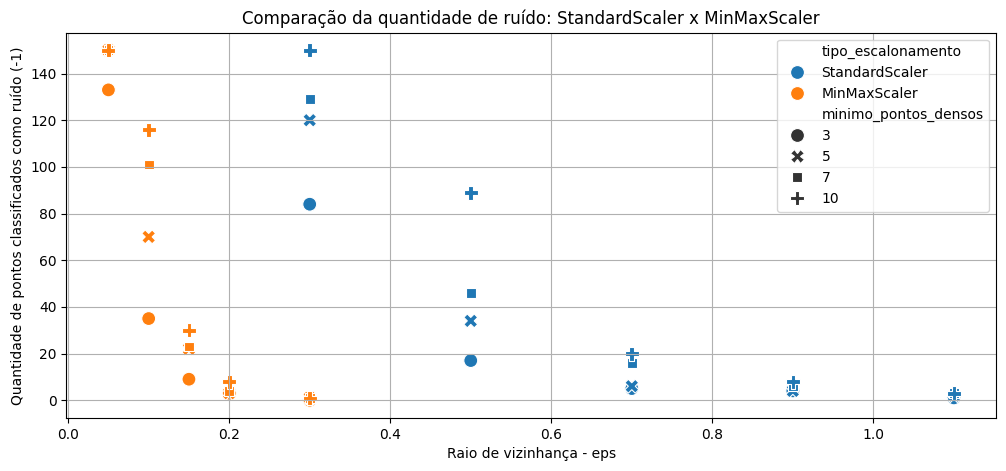

In [55]:
# =====================================================
# Comparando a quantidade de ruído entre os escalonadores
# =====================================================

plt.figure(figsize=(12, 5))

sns.scatterplot(
    data=tabela_comparacao_scalers,
    x="raio_vizinhanca_eps",
    y="quantidade_ruido",
    hue="tipo_escalonamento",
    style="minimo_pontos_densos",
    s=100
)

plt.title("Comparação da quantidade de ruído: StandardScaler x MinMaxScaler")
plt.xlabel("Raio de vizinhança - eps")
plt.ylabel("Quantidade de pontos classificados como ruído (-1)")
plt.grid(True)
plt.show()

---


Gráfico comparando ARI

---



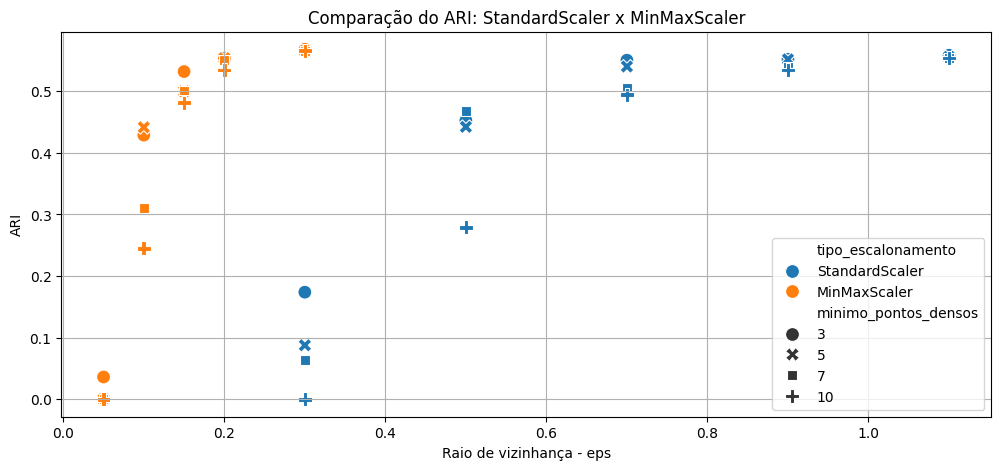

In [56]:
# =====================================================
# Comparando o ARI entre os escalonadores
# =====================================================

plt.figure(figsize=(12, 5))

sns.scatterplot(
    data=tabela_comparacao_scalers,
    x="raio_vizinhanca_eps",
    y="ARI",
    hue="tipo_escalonamento",
    style="minimo_pontos_densos",
    s=100
)

plt.title("Comparação do ARI: StandardScaler x MinMaxScaler")
plt.xlabel("Raio de vizinhança - eps")
plt.ylabel("ARI")
plt.grid(True)
plt.show()

### Análise do Exercício 2

Ao comparar `StandardScaler` com `MinMaxScaler`, foi possível observar que a forma de escalonamento influencia diretamente os resultados do DBSCAN.

Isso acontece porque o DBSCAN é um algoritmo baseado em distância. Como o parâmetro `eps` define o raio de vizinhança entre os pontos, qualquer mudança na escala dos dados altera as distâncias e, consequentemente, modifica os agrupamentos encontrados.

Com o `StandardScaler`, os melhores resultados ocorreram com valores maiores de `eps`, principalmente `eps = 1.1`. O melhor resultado com esse escalonador foi obtido com `eps = 1.1` e `min_samples = 3`, apresentando ARI de aproximadamente `0.558` e apenas 1 ponto classificado como ruído.

Com o `MinMaxScaler`, os melhores resultados ocorreram com valores menores de `eps`, pois esse escalonador transforma os dados para o intervalo entre 0 e 1. O melhor resultado geral foi obtido com `eps = 0.30` e `min_samples = 3`, apresentando ARI de aproximadamente `0.568`, Silhouette de aproximadamente `0.630` e nenhum ponto classificado como ruído.

Também foi possível observar que valores muito baixos de `eps` prejudicaram os dois escalonadores. No `StandardScaler`, `eps = 0.3` gerou grande quantidade de ruído. No `MinMaxScaler`, `eps = 0.05` também classificou muitos pontos como ruído, chegando a casos em que todos os 150 pontos foram considerados ruído.

Portanto, a comparação mostra que o escalonamento impacta diretamente o DBSCAN. O `MinMaxScaler` apresentou o melhor resultado neste teste específico, mas isso não significa que ele sempre será superior. O ponto mais importante é que, ao mudar o escalonador, também é necessário ajustar novamente o valor de `eps`, pois a escala dos dados muda.



---



## Exercício 3 — Comparando PCA com t-SNE

Neste exercício, vamos comparar duas técnicas de redução de dimensionalidade para visualização dos dados:

- `PCA`: técnica linear que projeta os dados em componentes principais.
- `t-SNE`: técnica não linear que tenta preservar relações locais entre os pontos.

Como o conjunto Iris possui 4 variáveis, essas técnicas serão usadas para reduzir os dados para 2 dimensões, permitindo visualizar os agrupamentos em gráficos.

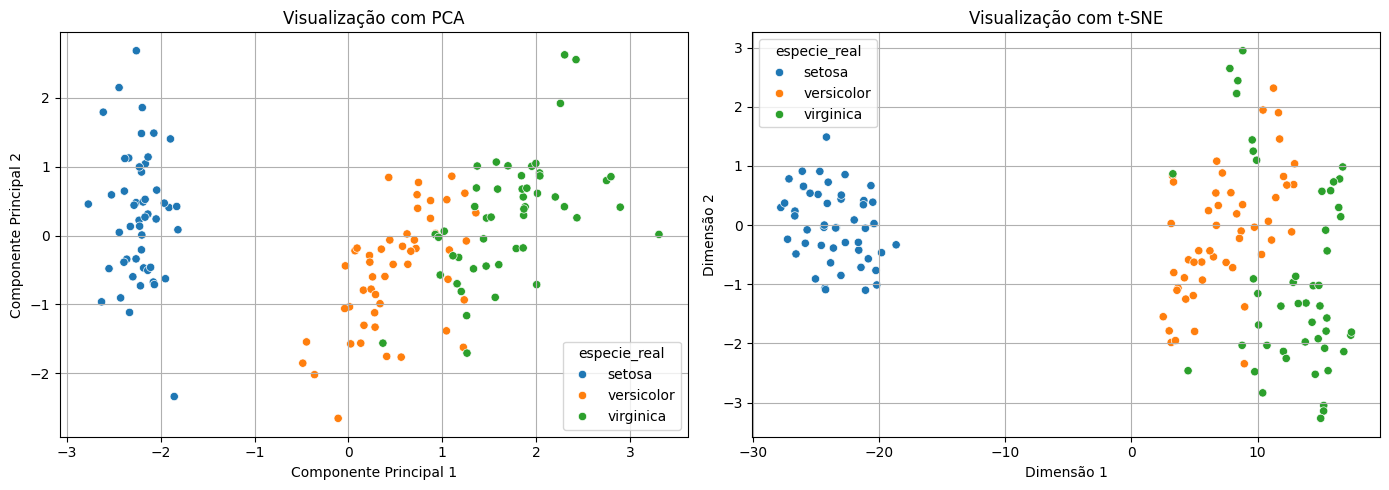

In [57]:
# =====================================================
# EXERCÍCIO 3 — Comparando PCA com t-SNE
# =====================================================
# O objetivo é comparar duas formas de reduzir os dados
# para 2 dimensões:
#
# - PCA: redução linear
# - t-SNE: redução não linear
#
# Isso ajuda a visualizar se os grupos ficam mais separados
# em uma técnica ou em outra.
# =====================================================


# =====================================================
# Aplicando PCA
# =====================================================
# O PCA reduz os dados para 2 componentes principais.
# Ele tenta preservar a maior parte da variância dos dados.
# =====================================================

modelo_pca = PCA(n_components=2, random_state=42)

dados_pca = modelo_pca.fit_transform(X_scaled)


# =====================================================
# Aplicando t-SNE
# =====================================================
# O t-SNE também reduz os dados para 2 dimensões,
# mas usa uma abordagem não linear.
#
# Ele tenta manter pontos parecidos próximos no gráfico.
# =====================================================

modelo_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

dados_tsne = modelo_tsne.fit_transform(X_scaled)


# =====================================================
# Criando tabelas para visualização
# =====================================================

tabela_pca = pd.DataFrame(
    dados_pca,
    columns=["Componente_1", "Componente_2"]
)

tabela_pca["especie_real"] = iris.target_names[y]


tabela_tsne = pd.DataFrame(
    dados_tsne,
    columns=["Dimensao_1", "Dimensao_2"]
)

tabela_tsne["especie_real"] = iris.target_names[y]


# =====================================================
# Visualizando PCA e t-SNE lado a lado
# =====================================================

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=tabela_pca,
    x="Componente_1",
    y="Componente_2",
    hue="especie_real",
    ax=eixos[0]
)

eixos[0].set_title("Visualização com PCA")
eixos[0].set_xlabel("Componente Principal 1")
eixos[0].set_ylabel("Componente Principal 2")
eixos[0].grid(True)


sns.scatterplot(
    data=tabela_tsne,
    x="Dimensao_1",
    y="Dimensao_2",
    hue="especie_real",
    ax=eixos[1]
)

eixos[1].set_title("Visualização com t-SNE")
eixos[1].set_xlabel("Dimensão 1")
eixos[1].set_ylabel("Dimensão 2")
eixos[1].grid(True)


plt.tight_layout()
plt.show()


---


Comparando DBSCAN no PCA e no t-SNE

---



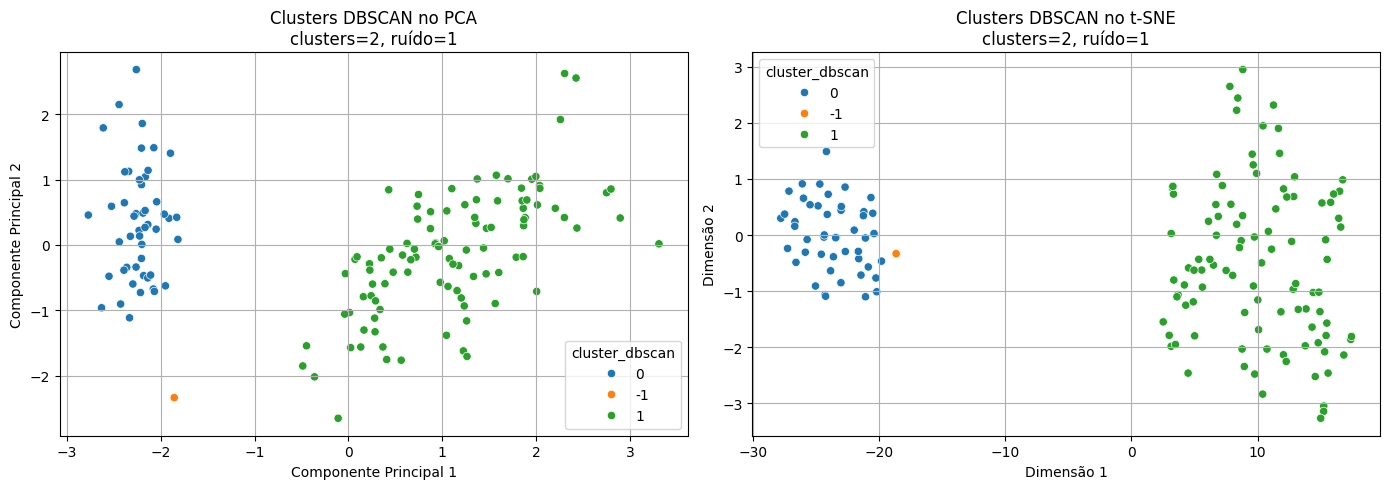

In [58]:
# =====================================================
# Comparando os clusters do DBSCAN no PCA e no t-SNE
# =====================================================
# Aqui vamos usar o DBSCAN com uma configuração que teve
# bom resultado no exercício anterior:
#
# eps = 1.1
# min_samples = 3
# =====================================================



# =====================================================
# Criando o DBSCAN
# =====================================================

modelo_dbscan_comparacao = DBSCAN(
    eps=1.1,
    min_samples=3
)


# =====================================================
# Treinando o DBSCAN nos dados padronizados
# =====================================================

rotulos_dbscan = modelo_dbscan_comparacao.fit_predict(X_scaled)


# =====================================================
# Adicionando os clusters nas tabelas PCA e t-SNE
# =====================================================

tabela_pca["cluster_dbscan"] = rotulos_dbscan.astype(str)
tabela_tsne["cluster_dbscan"] = rotulos_dbscan.astype(str)


# =====================================================
# Contando quantidade de clusters e ruído
# =====================================================

clusters_validos = [
    cluster
    for cluster in set(rotulos_dbscan)
    if cluster != -1
]

quantidade_clusters = len(clusters_validos)
quantidade_ruido = np.sum(rotulos_dbscan == -1)


# =====================================================
# Visualizando os clusters no PCA e no t-SNE
# =====================================================

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=tabela_pca,
    x="Componente_1",
    y="Componente_2",
    hue="cluster_dbscan",
    ax=eixos[0],
    palette="tab10"
)

eixos[0].set_title(
    f"Clusters DBSCAN no PCA\nclusters={quantidade_clusters}, ruído={quantidade_ruido}"
)

eixos[0].set_xlabel("Componente Principal 1")
eixos[0].set_ylabel("Componente Principal 2")
eixos[0].grid(True)


sns.scatterplot(
    data=tabela_tsne,
    x="Dimensao_1",
    y="Dimensao_2",
    hue="cluster_dbscan",
    ax=eixos[1],
    palette="tab10"
)

eixos[1].set_title(
    f"Clusters DBSCAN no t-SNE\nclusters={quantidade_clusters}, ruído={quantidade_ruido}"
)

eixos[1].set_xlabel("Dimensão 1")
eixos[1].set_ylabel("Dimensão 2")
eixos[1].grid(True)


plt.tight_layout()
plt.show()

### Análise do Exercício 3

Ao comparar PCA e t-SNE, foi possível observar diferenças importantes na forma como os dados são projetados em duas dimensões.

O PCA é uma técnica linear de redução de dimensionalidade. Ele tenta preservar a maior parte da variância global dos dados. No gráfico com PCA, a espécie setosa ficou bem separada, enquanto versicolor e virginica ficaram mais próximas e com certa sobreposição.

O t-SNE é uma técnica não linear. Ele busca preservar relações locais entre os pontos, ou seja, pontos parecidos tendem a ficar próximos na visualização. No gráfico com t-SNE, a separação visual entre os grupos ficou mais evidente, principalmente entre setosa e as demais espécies.

Ao visualizar os clusters do DBSCAN, foi observado que o algoritmo encontrou 2 clusters principais e apenas 1 ponto como ruído. Isso mostra que, para a configuração utilizada, o DBSCAN separou bem a setosa, mas agrupou versicolor e virginica em um mesmo grupo.

Esse resultado é coerente, pois versicolor e virginica possuem características mais parecidas no conjunto Iris. Como o DBSCAN é baseado em densidade, ele pode unir regiões próximas em um mesmo cluster, mesmo que existam classes reais diferentes.

Portanto, o t-SNE ajudou a visualizar melhor a separação local dos dados, enquanto o PCA mostrou a estrutura geral. O PCA é mais simples e interpretável, enquanto o t-SNE pode ser mais útil para visualização exploratória quando os dados possuem relações não lineares.